In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [2]:
url = "https://raw.githubusercontent.com/dibakar1612/decision-tree-and-k-means-clustering/2dcccdc262dfdbddcbac5ef6f8cec138030ca1a3/heart.csv"

df = pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print(df.shape)

df.info()

df.isnull().sum()
print("Dataset Shape:", df.shape)
display(df.head())


(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_4131/3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [5]:
cat_cols = df.select_dtypes(include='object').columns

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (820, 13)
Testing samples: (205, 13)


In [8]:
param_grid = {
    "max_depth": [2,3,4,5,6,7,8,10],
    "min_samples_split": [2,5,10,20]
}

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

cart_grid = GridSearchCV(
    estimator=cart,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

cart_grid.fit(X_train, y_train)

best_cart = cart_grid.best_estimator_

print("Best CART Parameters:")
print(cart_grid.best_params_)

Best CART Parameters:
{'max_depth': 10, 'min_samples_split': 2}


In [10]:
id3 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

id3_grid = GridSearchCV(
    estimator=id3,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

id3_grid.fit(X_train, y_train)

best_id3 = id3_grid.best_estimator_

print("Best ID3 Parameters:")
print(id3_grid.best_params_)

Best ID3 Parameters:
{'max_depth': 10, 'min_samples_split': 2}


In [11]:
cart_pred = best_cart.predict(X_test)
id3_pred = best_id3.predict(X_test)

cart_prob = best_cart.predict_proba(X_test)[:,1]
id3_prob = best_id3.predict_proba(X_test)[:,1]

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cart_metrics = {
    "Accuracy": accuracy_score(y_test, cart_pred),
    "Precision": precision_score(y_test, cart_pred),
    "Recall": recall_score(y_test, cart_pred),
    "F1": f1_score(y_test, cart_pred),
    "AUC": roc_auc_score(y_test, cart_prob)
}

id3_metrics = {
    "Accuracy": accuracy_score(y_test, id3_pred),
    "Precision": precision_score(y_test, id3_pred),
    "Recall": recall_score(y_test, id3_pred),
    "F1": f1_score(y_test, id3_pred),
    "AUC": roc_auc_score(y_test, id3_prob)
}

print("CART Metrics")
print(cart_metrics)

print("\nID3 Metrics")
print(id3_metrics)

CART Metrics
{'Accuracy': 0.9853658536585366, 'Precision': 1.0, 'Recall': 0.9714285714285714, 'F1': 0.9855072463768116, 'AUC': np.float64(0.9857142857142858)}

ID3 Metrics
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'AUC': np.float64(1.0)}


In [13]:
cart_pred = best_cart.predict(X_test)
id3_pred = best_id3.predict(X_test)

cart_prob = best_cart.predict_proba(X_test)[:,1]
id3_prob = best_id3.predict_proba(X_test)[:,1]

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cart_metrics = {
    "Accuracy": accuracy_score(y_test, cart_pred),
    "Precision": precision_score(y_test, cart_pred),
    "Recall": recall_score(y_test, cart_pred),
    "F1": f1_score(y_test, cart_pred),
    "AUC": roc_auc_score(y_test, cart_prob)
}

id3_metrics = {
    "Accuracy": accuracy_score(y_test, id3_pred),
    "Precision": precision_score(y_test, id3_pred),
    "Recall": recall_score(y_test, id3_pred),
    "F1": f1_score(y_test, id3_pred),
    "AUC": roc_auc_score(y_test, id3_prob)
}

print("CART Metrics")
print(cart_metrics)

print("\nID3 Metrics")
print(id3_metrics)

CART Metrics
{'Accuracy': 0.9853658536585366, 'Precision': 1.0, 'Recall': 0.9714285714285714, 'F1': 0.9855072463768116, 'AUC': np.float64(0.9857142857142858)}

ID3 Metrics
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'AUC': np.float64(1.0)}


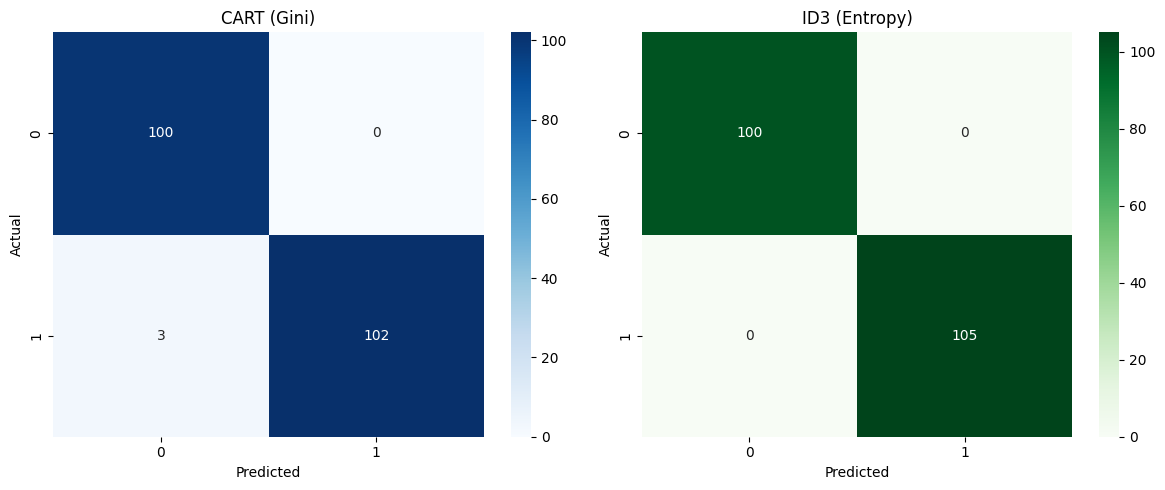

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test, cart_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("CART (Gini)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, id3_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("ID3 (Entropy)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

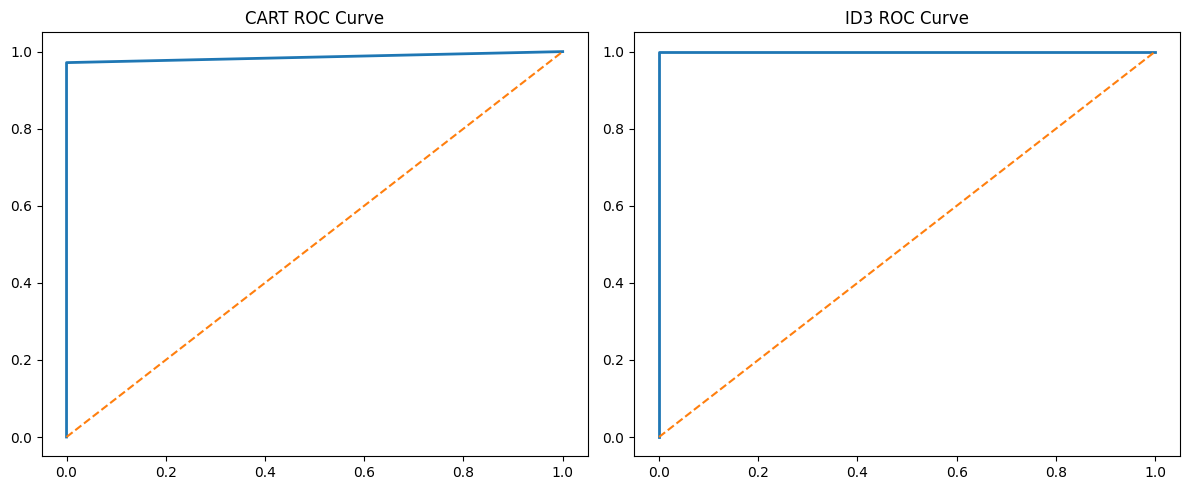

In [16]:
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(y_test, cart_prob)
fpr2, tpr2, _ = roc_curve(y_test, id3_prob)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].plot(fpr1, tpr1, linewidth=2)
ax[0].plot([0,1],[0,1],'--')
ax[0].set_title("CART ROC Curve")

ax[1].plot(fpr2, tpr2, linewidth=2)
ax[1].plot([0,1],[0,1],'--')
ax[1].set_title("ID3 ROC Curve")

plt.tight_layout()
plt.show()

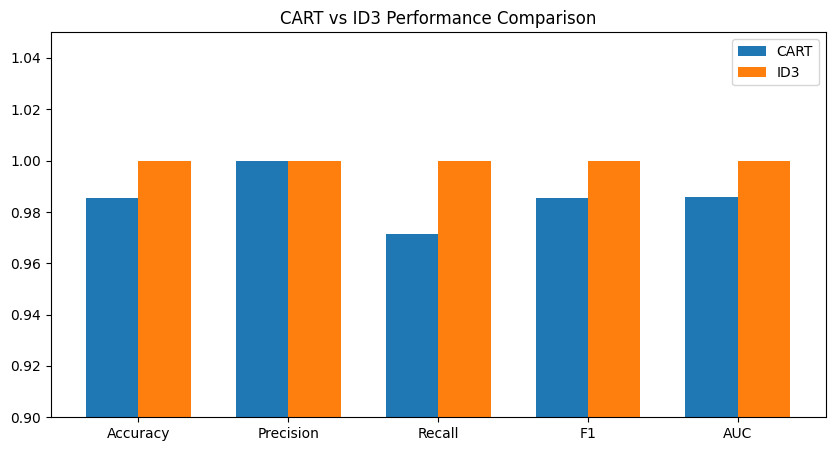

In [17]:
import numpy as np

metrics = list(cart_metrics.keys())

cart_values = list(cart_metrics.values())
id3_values = list(id3_metrics.values())

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    cart_values,
    width,
    label='CART'
)

plt.bar(
    x+width/2,
    id3_values,
    width,
    label='ID3'
)

plt.xticks(x, metrics)
plt.ylim(0.9,1.05)

plt.title("CART vs ID3 Performance Comparison")
plt.legend()

plt.show()

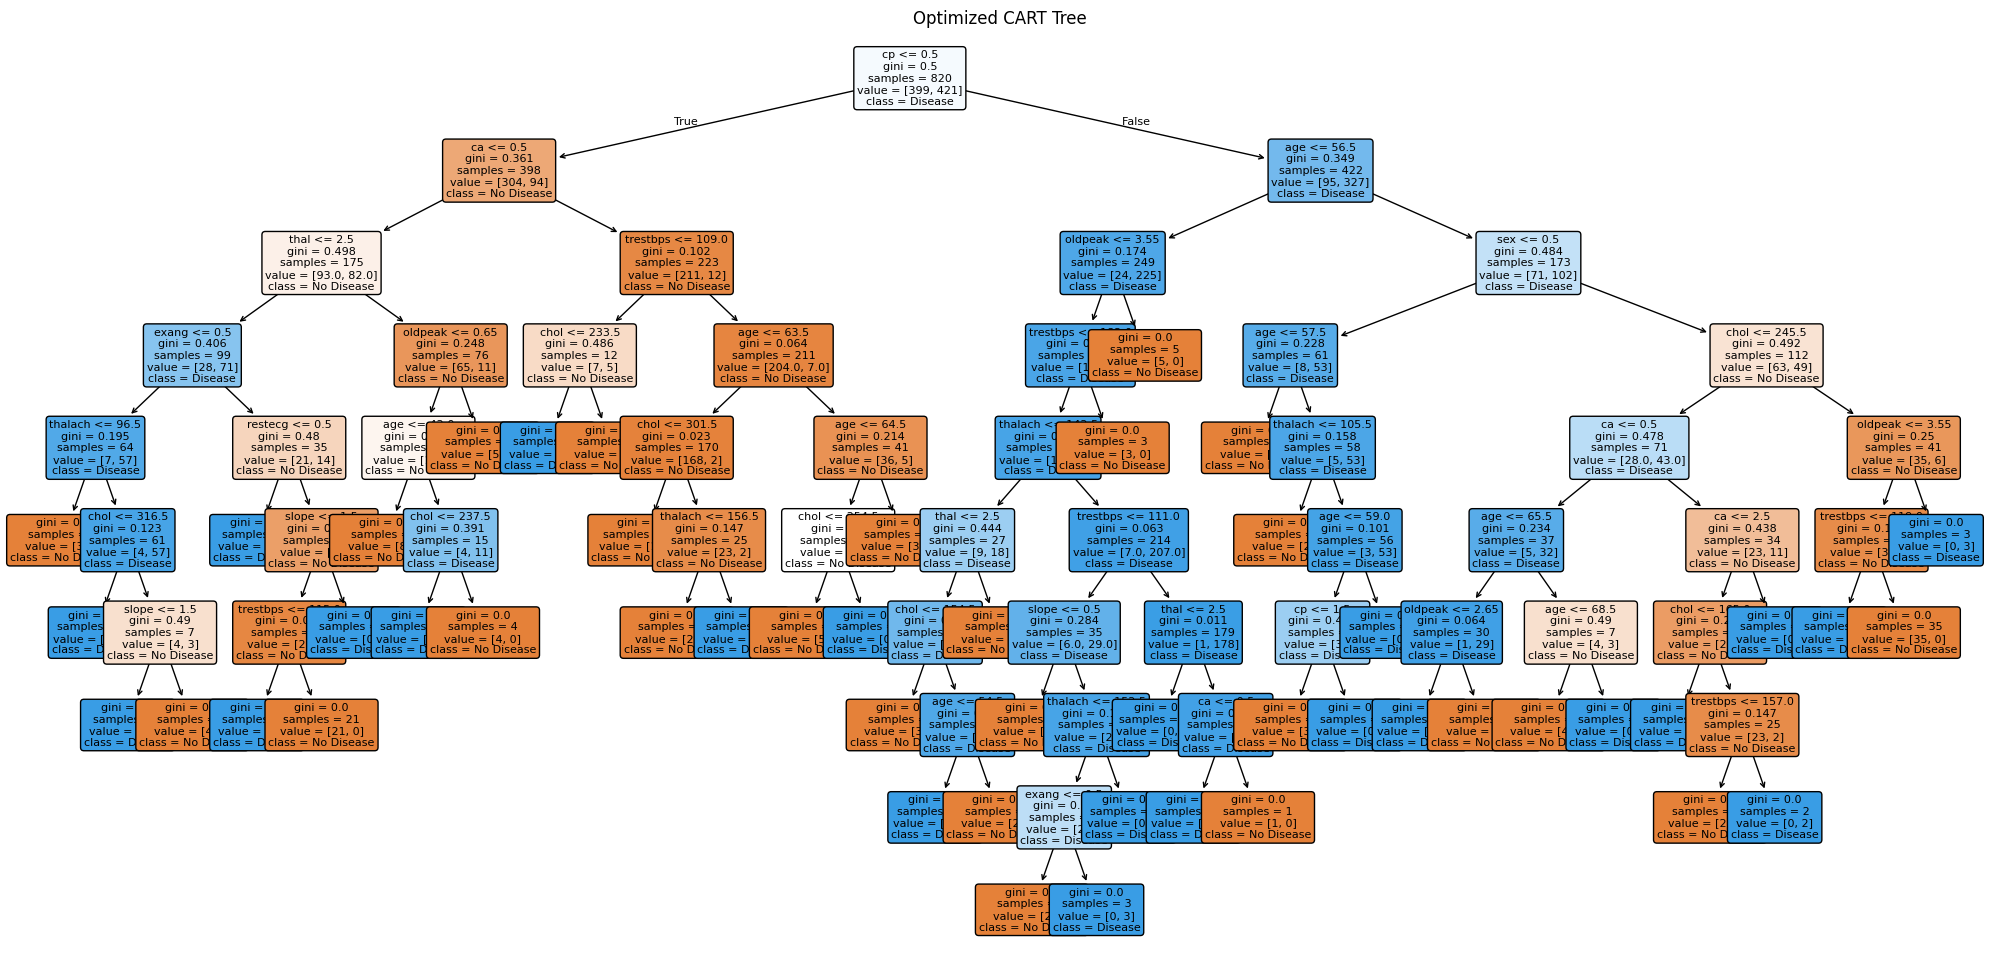

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,12))

plot_tree(
    best_cart,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Optimized CART Tree")
plt.show()

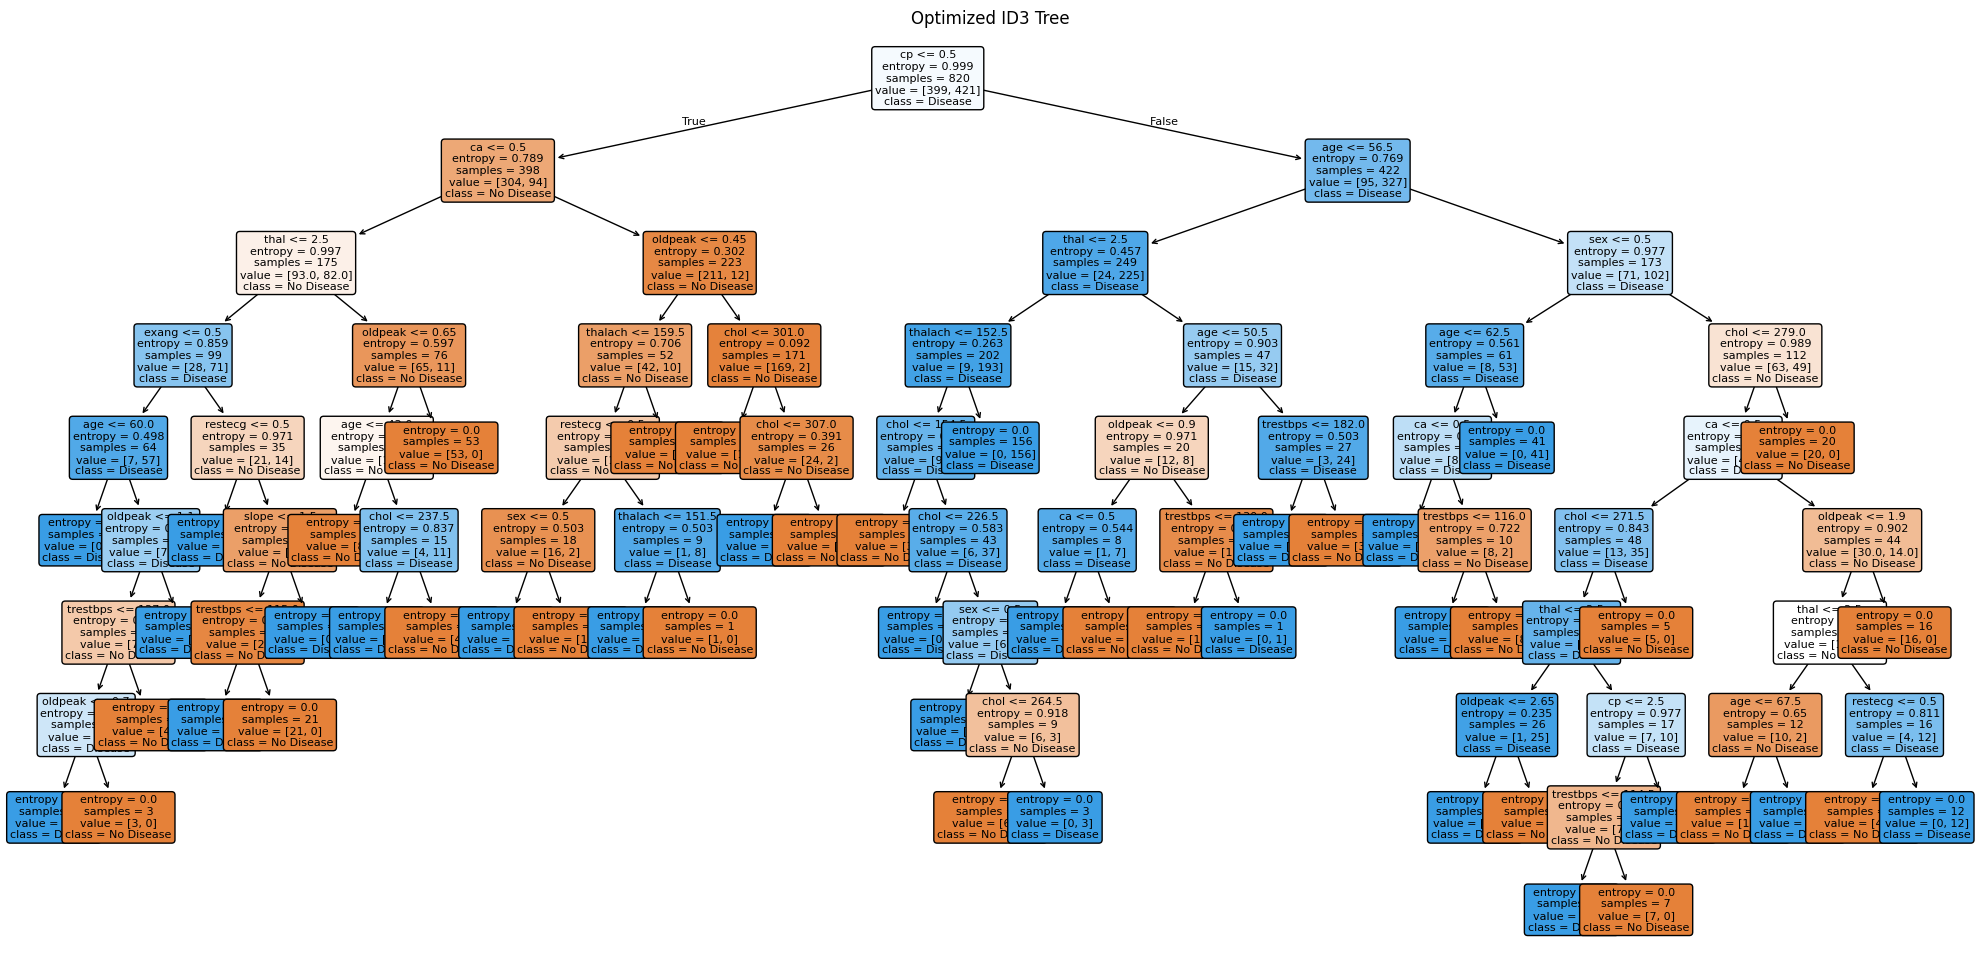

In [19]:
plt.figure(figsize=(25,12))

plot_tree(
    best_id3,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Optimized ID3 Tree")
plt.show()

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [21]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
cart_pca = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

id3_pca = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

cart_pca.fit(X_train_pca, y_train_pca)
id3_pca.fit(X_train_pca, y_train_pca)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

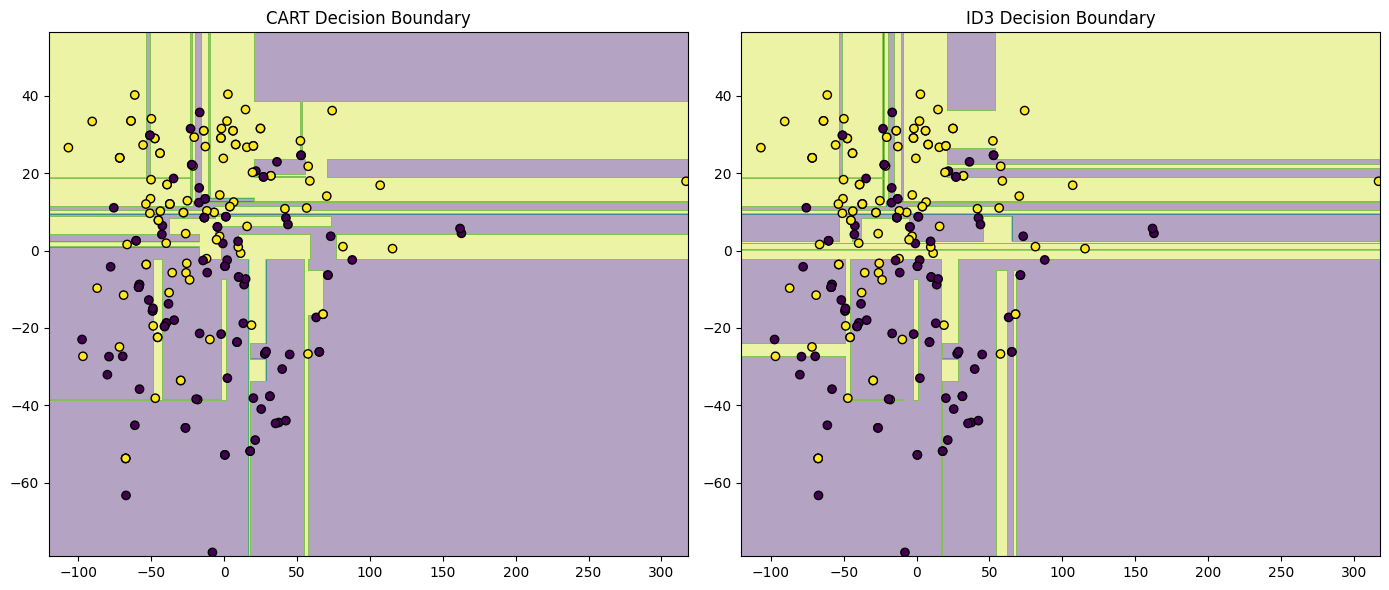

In [23]:
import numpy as np

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

fig, ax = plt.subplots(1,2, figsize=(14,6))

Z1 = cart_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)

ax[0].contourf(xx, yy, Z1, alpha=0.4)
ax[0].scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test_pca,
    edgecolor='k'
)
ax[0].set_title("CART Decision Boundary")

Z2 = id3_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z2 = Z2.reshape(xx.shape)

ax[1].contourf(xx, yy, Z2, alpha=0.4)
ax[1].scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test_pca,
    edgecolor='k'
)
ax[1].set_title("ID3 Decision Boundary")

plt.tight_layout()
plt.show()